In [90]:
import pandas as pd
import matplotlib.pyplot as plt

In [91]:
df = pd.read_csv("C:/Proyecto SQL_Python_PowerBI/Amazon/Amazon Sales Dataset.csv")

In [92]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Month'] = df['OrderDate'].dt.to_period('M')

In [93]:
#Model
df['Revenue'] = df['Quantity'] * df['UnitPrice'] * (1 - df['Discount'])
df['Cost_Product'] = df['Quantity'] * df['UnitPrice'] * 0.6
df['Fee'] = df['Revenue'] * 0.10

df['Profit'] = df['Revenue'] - (df['Cost_Product'] + df['Fee'] + df['ShippingCost'])

In [94]:
total_sales = df['TotalAmount'].sum()
total_profit = df['Profit'].sum()
margin = total_profit / total_sales

In [95]:
print(f"Total Sales: {total_sales:,.0f}")
print(f"Total Profit: {total_profit:,.0f}")
print(f"Margin: {margin:.2%}")

Total Sales: 91,825,648
Total Profit: 20,460,891
Margin: 22.28%


In [96]:
category_analysis = df.groupby('Category')[['TotalAmount','Profit']].sum()
category_analysis['Margin'] = category_analysis['Profit'] / category_analysis['TotalAmount']

print(category_analysis.to_string(formatters={
    'TotalAmount': '{:,.0f}'.format,
    'Profit': '{:,.0f}'.format,
    'Margin': '{:.2%}'.format
}))

                  TotalAmount    Profit Margin
Category                                      
Books              15,261,837 3,395,688 22.25%
Clothing           15,253,398 3,401,576 22.30%
Electronics        15,584,217 3,474,743 22.30%
Home & Kitchen     15,163,939 3,370,605 22.23%
Sports & Outdoors  15,345,572 3,420,680 22.29%
Toys & Games       15,216,685 3,397,598 22.33%


In [97]:
discount_analysis = df.groupby('Discount')[['TotalAmount','Profit']].mean().reset_index()

print(discount_analysis.to_string(index=False, formatters={
    'Discount': '{:.0%}'.format,
    'TotalAmount': '{:,.0f}'.format,
    'Profit': '{:,.0f}'.format
}))

Discount TotalAmount Profit
      0%         988    265
      5%         943    225
     10%         898    185
     15%         842    142
     20%         794    102
     25%         747     61
     30%         727     21


In [98]:
top = df.groupby('ProductName')['Profit'].mean().sort_values(ascending=False).head(10)

print(top.map('{:,.0f}'.format).to_string())

ProductName
Jeans                  217
Smartwatch             215
Kids Toy Car           212
Gaming Mouse           211
Mechanical Keyboard    211
Dress Shirt            211
Smartphone Case        210
Bluetooth Speaker      210
Laptop Sleeve          210
Memory Card 128GB      208


In [99]:
lowest = df.groupby('ProductName')['Profit'].mean().sort_values().head(10)

print(lowest.map('{:,.0f}'.format).to_string())

ProductName
USB-C Charger       196
Air Fryer           197
Portable SSD 1TB    199
Webcam Full HD      199
T-Shirt             200
Graphic Tablet      200
Wireless Charger    200
Desk Plant          200
Router              200
Drone Mini          201


In [100]:
customers = df.groupby('CustomerName')['Profit'].mean().sort_values(ascending=False).head(10)

print("Top customers:")
print(customers.map('{:,.0f}'.format).to_string())

Top customers:
CustomerName
Pooja Mehta     227
Rohit Kapoor    225
Pooja Kapoor    224
Simran Singh    224
Mohit Singh     224
Aarav Kumar     223
Vihaan Joshi    223
Aditya Gupta    223
Vivaan Patel    222
Sahil Gupta     222


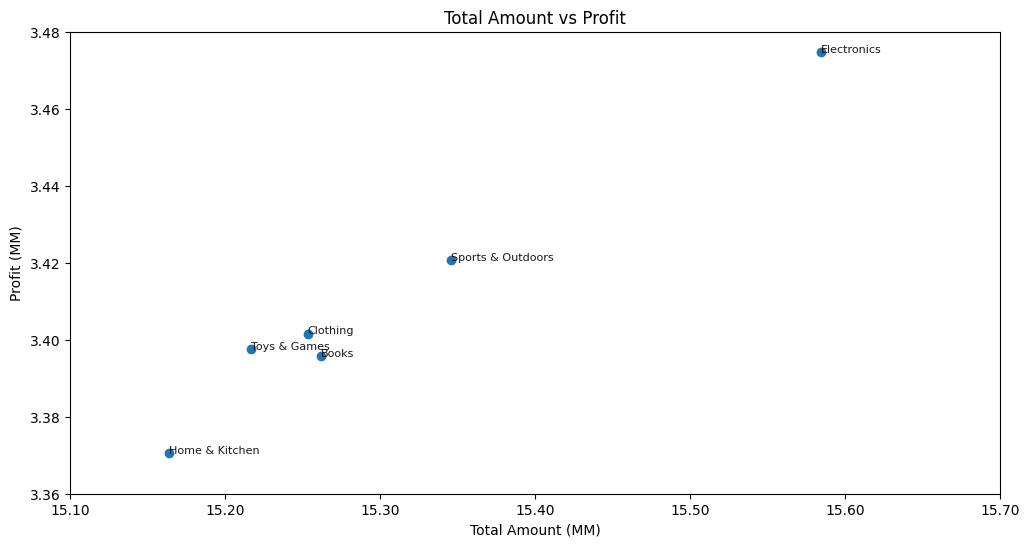

In [103]:
plt.figure(figsize=(12,6))

plt.scatter(category_analysis['TotalAmount'], category_analysis['Profit'])

# Etiquetas por punto
for i in category_analysis.index:
    plt.text(category_analysis['TotalAmount'][i],
             category_analysis['Profit'][i],
             i, fontsize=8, alpha=0.9)

plt.title('Total Amount vs Profit')
plt.xlabel('Total Amount (MM)')
plt.ylabel('Profit (MM)')

ax = plt.gca()

xticks = ax.get_xticks()
yticks = ax.get_yticks()

ax.set_xticks(xticks)
ax.set_yticks(yticks)

ax.set_xticklabels([f'{x/1000000:,.2f}' for x in xticks])
ax.set_yticklabels([f'{y/1000000:,.2f}' for y in yticks])

plt.show()